In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("resume_cleaned.csv")
df.head()

,ID,Resume_str,Resume_html,Category,char_length,word_length,Cleaned_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442,674,hr administrator/marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572,708,hr specialist u hr operation versatile medium ...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720,1017,hr director 20 year recruiting 15 plus year hu...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855,379,hr specialist dedicated driven dynamic 20 year...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172,1206,hr manager highlight hr hr department startup ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              2483 non-null   int64 
 1   Resume_str      2483 non-null   object
 2   Resume_html     2483 non-null   object
 3   Category        2483 non-null   object
 4   char_length     2483 non-null   int64 
 5   word_length     2483 non-null   int64 
 6   Cleaned_Resume  2483 non-null   object
dtypes: int64(3), object(4)
memory usage: 135.9+ KB


In [4]:
# Step 1: Separate Features & Target

X = df["Cleaned_Resume"]

y = df["Category"]

In [5]:
# Step 2: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Shape : (1986,)
Testing Shape  : (497,)

Training Labels : (1986,)
Testing Labels  : (497,)


In [7]:
# Step 3: Check Class Distribution

print("Training Distribution:")
print("-"*30)

print(y_train.value_counts())

print()

print("Testing Distribution")
print("-"*30)

print(y_test.value_counts())

Training Distribution:
------------------------------
Category
INFORMATION-TECHNOLOGY    96
BUSINESS-DEVELOPMENT      95
CHEF                      94
ENGINEERING               94
FINANCE                   94
ACCOUNTANT                94
FITNESS                   94
ADVOCATE                  94
SALES                     93
AVIATION                  93
HEALTHCARE                92
CONSULTANT                92
BANKING                   92
CONSTRUCTION              90
PUBLIC-RELATIONS          89
HR                        88
DESIGNER                  86
ARTS                      82
TEACHER                   82
APPAREL                   78
DIGITAL-MEDIA             77
AGRICULTURE               50
AUTOMOBILE                29
BPO                       18
Name: count, dtype: int64

Testing Distribution
------------------------------
Category
CHEF                      24
AVIATION                  24
ADVOCATE                  24
ENGINEERING               24
FINANCE                   24
INFORMAT

In [8]:
# Step 4: Build the NLP Pipeline

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [9]:
logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2),
            min_df=2,
            max_df=0.95,
        )
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [10]:
# Step 5: Train the First Model
logistic_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [11]:
# Step 6: Predictions

y_pred = logistic_pipeline.predict(
    X_test
)

In [12]:
# Step 7: Evaluate

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

print()

print(classification_report(
    y_test,
    y_pred
))

Accuracy : 0.6600

                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.31      0.46      0.37        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.58      0.33      0.42        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.71      0.77        24
               BANKING       0.84      0.70      0.76        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.50      0.92      0.65        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.81      0.77      0.79        22
            CONSULTANT       0.44      0.17      0.25        23
              DESIGNER       0.85      0.81      0.83        21
         DIGITAL-MED

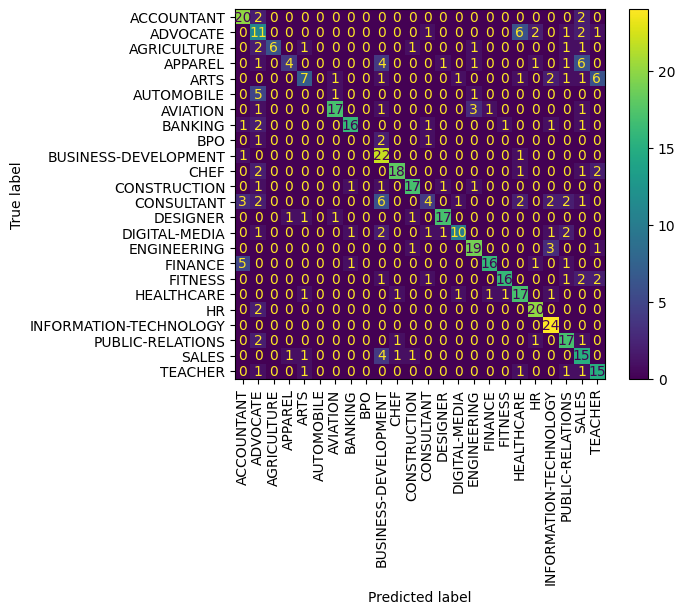

In [13]:
# Step 8: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.show()

## Model Comparison Framework

In [22]:
# Step 1: Import Models and Metrics

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import time

In [20]:
# Step 2: Create Model Dictionary

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

}

In [26]:
# Step 3: Train Every Model

# Create Results List
results = []


for model_name, model in models.items():

    print("-" * 50)
    print(model_name)

    pipeline = Pipeline([

        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                min_df=2,
                max_df=0.95,
                ngram_range=(1,2),
                sublinear_tf=True
            )
        ),

        (
            "classifier",
            model
        )
    ])

    start = time.time()

    pipeline.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "Training Time (sec)": training_time
    })

    print(f"Accuracy : {accuracy:.4f}")

--------------------------------------------------
Logistic Regression
Accuracy : 0.6338
--------------------------------------------------
Naive Bayes
Accuracy : 0.5594
--------------------------------------------------
Linear SVM
Accuracy : 0.7223
--------------------------------------------------
Random Forest
Accuracy : 0.7223


In [29]:
# Step 6: Results Table
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.633803,0.645958,0.633803,0.612674,5.441911
1,Naive Bayes,0.559356,0.552654,0.559356,0.512955,3.241182
2,Linear SVM,0.722334,0.724217,0.722334,0.711450,3.815163
3,Random Forest,0.722334,0.729880,0.722334,0.697784,17.915973


In [36]:
# Step 7: Sort Models

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False,
    ignore_index=True
)

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Linear SVM,0.7223,0.7242,0.7223,0.7115,3.8152
1,Random Forest,0.7223,0.7299,0.7223,0.6978,17.9160
2,Logistic Regression,0.6338,0.6460,0.6338,0.6127,5.4419
3,Naive Bayes,0.5594,0.5527,0.5594,0.5130,3.2412


### Selected Linear SVM Model!

## Hyperparameter Tuning

In [37]:
# Complete Search Space

param_grid = {

    "tfidf__max_features": [
        3000,
        5000,
        7000
    ],

    "tfidf__min_df": [
        2,
        3,
        5
    ],

    "tfidf__ngram_range": [
        (1,1),
        (1,2)
    ],

    "classifier__C": [
        0.1,
        1,
        5,
        10
    ]

}

In [38]:
# Build the Pipeline

pipeline = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True
        )
    ),

    (
        "classifier",
        LinearSVC(
            random_state=42
        )
    )

])

In [40]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2

)

In [41]:
# Train

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.1, 1, ...], 'tfidf__max_features': [3000, 5000, ...], 'tfidf__min_df': [2, 3, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [42]:
print("Best Accuracy:")
print(grid_search.best_score_)

print()

print("Best Parameters:")
print(grid_search.best_params_)

Best Accuracy:
0.6893282533574674

Best Parameters:
{'classifier__C': 1, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


## Final Model Evaluation - Linear SVM

In [45]:
best_pipeline = grid_search.best_estimator_

predictions = best_pipeline.predict(X_test)

In [46]:
# Accuracy and Classification Report

print(
    accuracy_score(y_test, predictions)
)

print(
    classification_report(
        y_test,
        predictions
    )
)

0.7223340040241448
                        precision    recall  f1-score   support

            ACCOUNTANT       0.66      0.79      0.72        24
              ADVOCATE       0.86      0.75      0.80        24
           AGRICULTURE       0.88      0.54      0.67        13
               APPAREL       0.69      0.47      0.56        19
                  ARTS       0.62      0.38      0.47        21
            AUTOMOBILE       1.00      0.43      0.60         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.82      0.78      0.80        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.59      0.92      0.72        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.70      0.30      0.42        23
              DESIGNER       0.80      0.95      0.87        21
         DIGITAL-MED

In [107]:
# 1) Confusion Matrix

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix
)

In [110]:
# 2) Generate Predictions
y_pred = best_pipeline.predict(X_test)

In [111]:
# 3) Compute Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_pipeline.classes_
)

<Figure size 1600x1600 with 0 Axes>

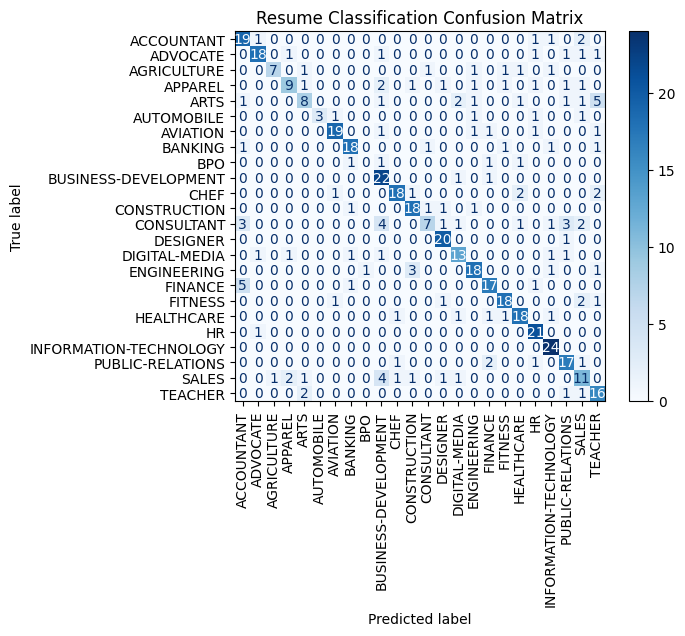

In [113]:
# 4) Plot
plt.figure(figsize=(16,16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_pipeline.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Resume Classification Confusion Matrix")

plt.show()

In [114]:
# 5) Top 10 Most Confused Category Pairs

labels = best_pipeline.classes_

cm_copy = cm.copy()

# Ignore correct predictions
np.fill_diagonal(cm_copy, 0)

pairs = []

for i in range(len(labels)):
    for j in range(len(labels)):
        if cm_copy[i, j] > 0:
            pairs.append([
                labels[i],
                labels[j],
                cm_copy[i, j]
            ])

confusion_df = pd.DataFrame(
    pairs,
    columns=[
        "Actual",
        "Predicted",
        "Count"
    ]
)

confusion_df = confusion_df.sort_values(
    "Count",
    ascending=False
)

confusion_df.head(10)

,Actual,Predicted,Count
32,ARTS,TEACHER,5
80,FINANCE,ACCOUNTANT,5
100,SALES,BUSINESS-DEVELOPMENT,4
62,CONSULTANT,BUSINESS-DEVELOPMENT,4
77,ENGINEERING,CONSTRUCTION,3
67,CONSULTANT,PUBLIC-RELATIONS,3
61,CONSULTANT,ACCOUNTANT,3
94,PUBLIC-RELATIONS,FINANCE,2
27,ARTS,DIGITAL-MEDIA,2
85,FITNESS,SALES,2


## Save the Pipeline and Model

In [47]:
import joblib

joblib.dump(
    best_pipeline,
    "artifacts/resume_classifier.pkl"
)

print("Model and Pipeline Saved Successfully!")

Model and Pipeline Saved Successfully!


In [49]:
# Test Loading the Pipeline and Model

model = joblib.load(
    "artifacts/resume_classifier.pkl"
)

print("Model and Pipeline Loaded Successfully!")

Model and Pipeline Loaded Successfully!


In [100]:
# Predict on 1 resume

sample_resume = df.loc[2440, "Resume_str"]

In [101]:
# prediction

prediction = model.predict(
    [sample_resume]
)

print(prediction)

['AVIATION']


In [106]:
# Test on Test-Data

import random

random.seed(42)

indices = random.sample(range(len(X_test)), 20)

correct = 0

for idx in indices:

    resume = X_test.iloc[idx]

    actual = y_test.iloc[idx]

    predicted = model.predict([resume])[0]

    print("-"*60)
    print(f"Actual    : {actual}")
    print(f"Predicted : {predicted}")

    if actual == predicted:
        correct += 1

print(f"\nCorrect: {correct}/20")

------------------------------------------------------------
Actual    : ADVOCATE
Predicted : HR
------------------------------------------------------------
Actual    : BUSINESS-DEVELOPMENT
Predicted : BUSINESS-DEVELOPMENT
------------------------------------------------------------
Actual    : ADVOCATE
Predicted : ADVOCATE
------------------------------------------------------------
Actual    : CONSULTANT
Predicted : SALES
------------------------------------------------------------
Actual    : HEALTHCARE
Predicted : HEALTHCARE
------------------------------------------------------------
Actual    : HR
Predicted : HR
------------------------------------------------------------
Actual    : BUSINESS-DEVELOPMENT
Predicted : BUSINESS-DEVELOPMENT
------------------------------------------------------------
Actual    : INFORMATION-TECHNOLOGY
Predicted : INFORMATION-TECHNOLOGY
------------------------------------------------------------
Actual    : PUBLIC-RELATIONS
Predicted : PUBLIC-RELATI